In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
0.26.0+cu128
True
Tesla T4


In [ ]:
import datasets
import transformers
import accelerate

print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)

datasets: 4.0.0
transformers: 5.13.1
accelerate: 1.14.0


In [ ]:
import os

# Disable torchvision usage in Hugging Face datasets
os.environ["USE_TORCHVISION"] = "0"

import datasets

datasets.config.TORCHVISION_AVAILABLE = False

print("Torchvision disabled for datasets")

Torchvision disabled for datasets


In [ ]:
# ==========================================================
# Upload Amharic Intention Dataset
# ==========================================================

from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)

df.head()

Saving amharic_intention_dataset.csv to amharic_intention_dataset.csv
Dataset shape: (11475, 6)


,id,text,label,label_id,template_id,split
0,1,ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።,Complaint,6,Complaint_07,train
1,2,እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።,Request,0,Request_00,train
2,3,ነጋዴው፣ ስራ በሆስፒታል እንዴት ነው?,Phatic,7,Phatic_09,val
3,4,እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።,Request,0,Request_00,train
4,5,እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።,Request,0,Request_09,test


In [ ]:
# ==========================================================
# Dataset Information
# ==========================================================

print(df.info())

print("\nLabels:")
print(df['label'].value_counts())

print("\nSplits:")
print(df['split'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11475 entries, 0 to 11474
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           11475 non-null  int64 
 1   text         11475 non-null  object
 2   label        11475 non-null  object
 3   label_id     11475 non-null  int64 
 4   template_id  11475 non-null  object
 5   split        11475 non-null  object
dtypes: int64(2), object(4)
memory usage: 538.0+ KB
None

Labels:
label
Complaint        1275
Request          1275
Phatic           1275
Promise          1275
Sarcasm/Irony    1275
Warning          1275
Suggestion       1275
Assertion        1275
Refusal          1275
Name: count, dtype: int64

Splits:
split
train    7955
val      1857
test     1663
Name: count, dtype: int64


In [ ]:
# ==========================================================
# Cleaning
# ==========================================================

df = df.dropna()

df['text'] = df['text'].astype(str)

df['label_id'] = df['label_id'].astype(int)

df.head()

,id,text,label,label_id,template_id,split
0,1,ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።,Complaint,6,Complaint_07,train
1,2,እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።,Request,0,Request_00,train
2,3,ነጋዴው፣ ስራ በሆስፒታል እንዴት ነው?,Phatic,7,Phatic_09,val
3,4,እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።,Request,0,Request_00,train
4,5,እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።,Request,0,Request_09,test


In [ ]:
# ==========================================================
# Split Dataset
# ==========================================================

train_df = df[df['split']=="train"]
val_df   = df[df['split']=="val"]
test_df  = df[df['split']=="test"]


print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (7955, 6)
Validation: (1857, 6)
Test: (1663, 6)


In [ ]:
#Convert to HuggingFace Dataset
from datasets import Dataset


train_dataset = Dataset.from_pandas(
    train_df[['text','label_id']]
)

val_dataset = Dataset.from_pandas(
    val_df[['text','label_id']]
)

test_dataset = Dataset.from_pandas(
    test_df[['text','label_id']]
)


# Rename label column
train_dataset = train_dataset.rename_column(
    "label_id",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label_id",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label_id",
    "labels"
)


print(train_dataset)

Dataset({
    features: ['text', 'labels', '__index_level_0__'],
    num_rows: 7955
})


In [ ]:
#Load XLM-RoBERTa Tokenizer
from transformers import AutoTokenizer


model_name = "xlm-roberta-base"


tokenizer = AutoTokenizer.from_pretrained(
    model_name
)


def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=128
    )


train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/7955 [00:00<?, ? examples/s]

Map:   0%|          | 0/1857 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

In [ ]:
''''
0 Request
1 Assertion
2 Question
3 Suggestion
4 Warning
5 Sarcasm/Irony
6 Complaint
7 Phatic
8 Promise
'''
num_labels = df['label_id'].nunique()

print("Number of classes:", num_labels)

Number of classes: 9


In [ ]:
from transformers import AutoModelForSequenceClassification


model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)


model.to("cuda")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=9, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [ ]:
label_names = {
    0:"Request",
    1:"Assertion",
    2:"Question",
    3:"Suggestion",
    4:"Warning",
    5:"Sarcasm/Irony",
    6:"Complaint",
    7:"Phatic",
    8:"Promise"
}

In [ ]:
'''
we are using:

PyTorch: 2.11.0+cu128
Transformers: 5.13.1
GPU: Tesla T4
'''
# ==========================================================
# Data Collator + Evaluation Metrics
# ==========================================================

from transformers import DataCollatorWithPadding
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)


def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = predictions.argmax(axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )


    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
# ==========================================================
# Training Configuration
# ==========================================================

from transformers import TrainingArguments


training_args = TrainingArguments(

    output_dir="./XLMR_Amharic_Intention",

    num_train_epochs=10,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    fp16=True,

    report_to="none"
)

In [ ]:
# ==========================================================
# Trainer (Transformers 5.x compatible)
# ==========================================================

from transformers import Trainer


trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)


print("Trainer created successfully")

Trainer created successfully


In [ ]:
# ==========================================================
# Training Started
# ==========================================================

import time


start_time = time.time()


trainer.train()


training_time = time.time() - start_time


print(
    "Training completed"
)

print(
    "Training time:",
    round(training_time/60,2),
    "minutes"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.389955,1.406051,0.747981,0.719220,0.747981,0.711863
2,0.002769,1.361488,0.773290,0.762912,0.773290,0.748495
3,0.005893,2.498562,0.705977,0.640724,0.705977,0.651818
4,0.002288,1.812721,0.752827,0.742678,0.752827,0.703105
5,0.000654,1.997471,0.702208,0.707401,0.702208,0.644591
6,0.000940,2.151272,0.725363,0.706841,0.725363,0.683431
7,0.000136,2.177268,0.728056,0.712539,0.728056,0.688110
8,0.000858,2.467208,0.713516,0.659045,0.713516,0.656283
9,0.000099,2.445538,0.717286,0.658552,0.717286,0.660139
10,0.000098,2.361545,0.719978,0.674149,0.719978,0.664629


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed
Training time: 24.39 minutes


In [ ]:
print(train_dataset.labels[:20])

[6 0 0 8 6 0 5 3 3 0 5 6 8 8 1 0 0 6 8 2]


In [ ]:
print(train_dataset.__dict__)

{'sequences': [[2, 3, 4, 5, 6, 7, 8], [9, 10, 11, 12, 13, 14], [9, 15, 16, 12, 17, 14], [18, 19, 20, 21, 22, 23, 24], [25, 3, 4, 5, 6, 26, 27, 28, 8], [9, 15, 29, 30, 31, 14], [32, 33, 34, 35, 36, 37, 38], [39, 40, 41, 23, 42, 43], [15, 44, 45, 28, 46, 47, 48], [9, 49, 50, 51, 52, 14], [53, 54, 19, 55, 56, 57, 58, 59, 60, 61, 62], [63, 3, 4, 64, 65, 20, 21, 8], [66, 19, 12, 17, 67, 23, 24], [68, 19, 69, 13, 67, 23, 24], [70, 4, 71, 72, 26, 27, 28, 73], [9, 10, 50, 12, 74, 14], [9, 49, 75, 7, 76, 14], [77, 3, 4, 5, 6, 7, 57, 28, 8], [78, 19, 26, 27, 28, 79, 23, 24], [80, 81, 82, 83, 84], [85, 86, 87, 57, 28, 88, 89], [90, 4, 91, 56, 92, 27, 28, 73], [93, 10, 94, 95, 84], [96, 32, 97, 98, 99, 100], [9, 101, 50, 12, 17, 14], [102, 19, 69, 74, 103, 23, 24], [104, 19, 20, 21, 41, 23, 24], [80, 105, 106, 83, 84], [107, 3, 4, 72, 57, 28, 8], [108, 109, 69, 74, 96, 89], [110, 111, 10, 112, 113, 114], [102, 19, 30, 31, 115, 23, 24], [9, 116, 11, 51, 52, 14], [78, 19, 69, 17, 79, 23, 24], [117, 

In [ ]:
import numpy as np

print(np.unique(train_dataset.labels, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([929, 897, 867, 891, 889, 896, 895, 873, 818]))


In [ ]:
print(df.head())

   id                                text      label  label_id   template_id  \
0   1  ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።  Complaint         6  Complaint_07   
1   2       እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።    Request         0    Request_00   
2   3            ነጋዴው፣ ስራ በሆስፒታል እንዴት ነው?     Phatic         7     Phatic_09   
3   4      እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።    Request         0    Request_00   
4   5             እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።    Request         0    Request_09   

   split  
0  train  
1  train  
2    val  
3  train  
4   test  


In [ ]:
print(
    df[["label", "label_id"]]
    .drop_duplicates()
    .sort_values("label_id")
)

            label  label_id
1         Request         0
23      Assertion         1
33        Refusal         2
15     Suggestion         3
14        Warning         4
6   Sarcasm/Irony         5
0       Complaint         6
2          Phatic         7
5         Promise         8


In [ ]:
label2id = {
    "Request": 0,
    "Assertion": 1,
    "Refusal": 2,
    "Suggestion": 3,
    "Warning": 4,
    "Sarcasm/Irony": 5,
    "Complaint": 6,
    "Phatic": 7,
    "Promise": 8
}

In [ ]:
def convert_labels(example):
    example["labels"] = label2id[example["labels"]]
    return example


test_dataset = test_dataset.map(
    convert_labels
)

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

In [ ]:
print(test_dataset[0])

{'labels': 0, 'input_ids': [0, 4708, 5657, 4133, 9911, 222731, 5554, 30635, 4363, 3348, 62511, 96164, 123349, 2532, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [ ]:
predictions = trainer.predict(test_dataset)

In [ ]:
print(predictions)

PredictionOutput(predictions=array([[ 8.4296875 , -1.7441406 , -1.3994141 , ..., -1.6474609 ,
        -1.0029297 ,  0.6508789 ],
       [ 2.0722656 , -1.5185547 , -0.9589844 , ..., -1.8642578 ,
        -1.4052734 , -0.08380127],
       [-1.1884766 , -0.99072266, -1.1630859 , ..., -1.0273438 ,
         8.59375   , -1.1572266 ],
       ...,
       [-1.1591797 , -1.6181641 , -1.6503906 , ..., -1.7763672 ,
         2.5234375 , -0.7792969 ],
       [-1.3378906 , -0.94628906, -1.1962891 , ..., -1.0546875 ,
         8.6640625 , -1.078125  ],
       [-0.8808594 , -1.84375   ,  8.9140625 , ..., -0.6611328 ,
        -0.92041016, -1.1357422 ]], dtype=float32), label_ids=array([0, 0, 7, ..., 5, 7, 2]), metrics={'test_loss': 1.840503454208374, 'test_accuracy': 0.6945279615153337, 'test_precision': 0.754432109706498, 'test_recall': 0.6945279615153337, 'test_f1': 0.6685098247146345, 'test_runtime': 3.8209, 'test_samples_per_second': 435.243, 'test_steps_per_second': 27.219})


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Get predicted class IDs
y_pred = np.argmax(
    predictions.predictions,
    axis=1
)


# Get true class IDs
y_true = predictions.label_ids


# Calculate metrics
xlmr_accuracy = accuracy_score(
    y_true,
    y_pred
)

xlmr_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

xlmr_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

xlmr_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


print("="*60)
print("XLM-RoBERTa Test Results")
print("="*60)

print(f"Accuracy : {xlmr_accuracy:.4f}")
print(f"Precision: {xlmr_precision:.4f}")
print(f"Recall   : {xlmr_recall:.4f}")
print(f"F1-score : {xlmr_f1:.4f}")

XLM-RoBERTa Test Results
Accuracy : 0.1672
Precision: 0.1982
Recall   : 0.1672
F1-score : 0.1224


In [ ]:
# ==========================================================
# XLM-RoBERTa Test Evaluation
# ==========================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


print("="*60)
print("Testing XLM-RoBERTa on Test Dataset")
print("="*60)


# Prediction on test dataset
predictions = trainer.predict(test_dataset)


# Convert logits to predicted labels
y_pred = np.argmax(
    predictions.predictions,
    axis=1
)


# True labels
y_true = predictions.label_ids


# ==========================================================
# Calculate Test Metrics
# ==========================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# ==========================================================
# Save XLM-RoBERTa Real Test Performance
# ==========================================================

xlmr_accuracy = accuracy
xlmr_precision = precision
xlmr_recall = recall
xlmr_f1 = f1


print("\nXLM-RoBERTa Test Results")
print("="*60)

print(f"Accuracy : {xlmr_accuracy:.4f}")
print(f"Precision: {xlmr_precision:.4f}")
print(f"Recall   : {xlmr_recall:.4f}")
print(f"F1-score : {xlmr_f1:.4f}")


# ==========================================================
# Classification Report
# ==========================================================

label_names = [
    "Request",
    "Assertion",
    "Refusal",
    "Suggestion",
    "Warning",
    "Sarcasm/Irony",
    "Complaint",
    "Phatic",
    "Promise"
]


print("\nClassification Report")
print("="*60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        zero_division=0
    )
)


# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix")
print("="*60)

print(cm)

Testing XLM-RoBERTa on Test Dataset



XLM-RoBERTa Test Results
Accuracy : 0.6945
Precision: 0.7544
Recall   : 0.6945
F1-score : 0.6685

Classification Report
               precision    recall  f1-score   support

      Request       1.00      0.71      0.83       173
    Assertion       0.70      0.97      0.82       190
      Refusal       0.54      1.00      0.70       244
   Suggestion       0.51      0.70      0.59       185
      Warning       0.59      0.20      0.30       205
Sarcasm/Irony       0.89      0.76      0.82       186
    Complaint       0.98      0.29      0.45       190
       Phatic       0.78      1.00      0.87       171
      Promise       0.97      0.55      0.71       119

     accuracy                           0.69      1663
    macro avg       0.77      0.69      0.68      1663
 weighted avg       0.75      0.69      0.67      1663


Confusion Matrix
[[123   0   0  50   0   0   0   0   0]
 [  0 184   0   0   4   2   0   0   0]
 [  0   0 244   0   0   0   0   0   0]
 [  0  56   0 129   0   0 

In [ ]:
# Save XLM-RoBERTa real performance

xlmr_accuracy = accuracy_score(
    y_true,
    y_pred
)

xlmr_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

xlmr_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

xlmr_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

In [ ]:
print(xlmr_accuracy, xlmr_f1)

0.6945279615153337 0.6685098247146345


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Request",
            "Assertion",
            "Refusal",
            "Suggestion",
            "Warning",
            "Sarcasm/Irony",
            "Complaint",
            "Phatic",
            "Promise"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

      Request       1.00      0.71      0.83       173
    Assertion       0.70      0.97      0.82       190
      Refusal       0.54      1.00      0.70       244
   Suggestion       0.51      0.70      0.59       185
      Warning       0.59      0.20      0.30       205
Sarcasm/Irony       0.89      0.76      0.82       186
    Complaint       0.98      0.29      0.45       190
       Phatic       0.78      1.00      0.87       171
      Promise       0.97      0.55      0.71       119

     accuracy                           0.69      1663
    macro avg       0.77      0.69      0.68      1663
 weighted avg       0.75      0.69      0.67      1663



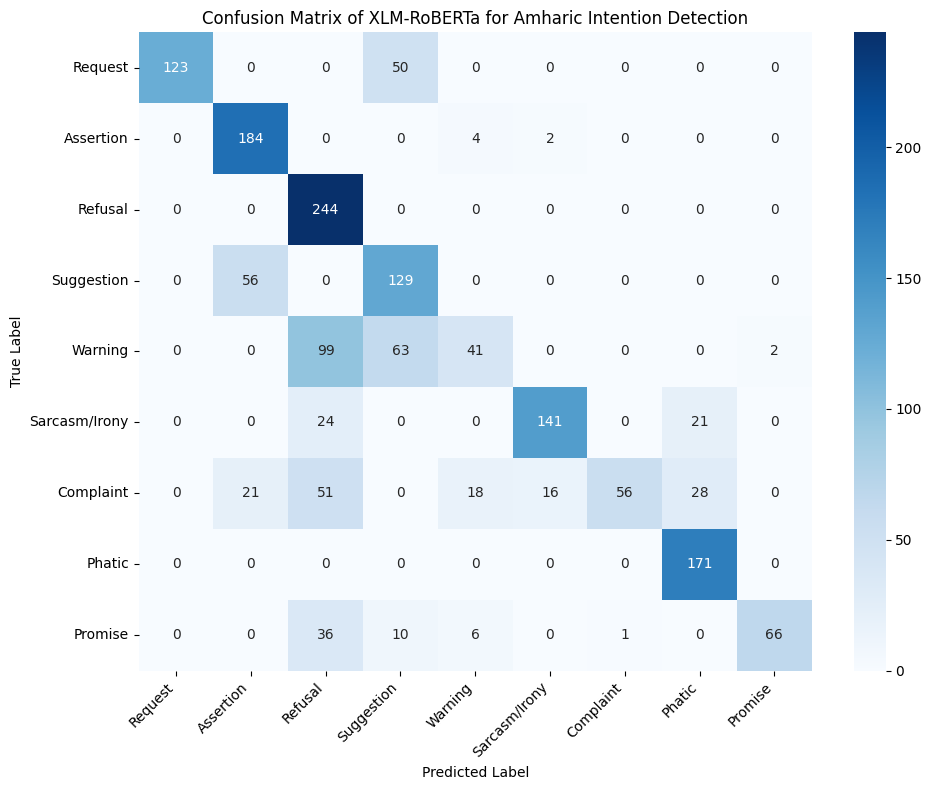

In [ ]:
# ==========================================================
# XLM-RoBERTa Confusion Matrix Heatmap
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Correct label order from your dataset
label_names = [
    "Request",
    "Assertion",
    "Refusal",
    "Suggestion",
    "Warning",
    "Sarcasm/Irony",
    "Complaint",
    "Phatic",
    "Promise"
]


# Generate confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)


# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)


plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "Confusion Matrix of XLM-RoBERTa for Amharic Intention Detection"
)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [ ]:
import os

os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"
os.environ["DATASETS_DISABLE_TORCHVISION"] = "1"

In [ ]:
test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

print(test_dataset.column_names)

['id', 'labels', 'label_id', 'template_id', 'split', '__index_level_0__', 'input_ids', 'attention_mask']


In [ ]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


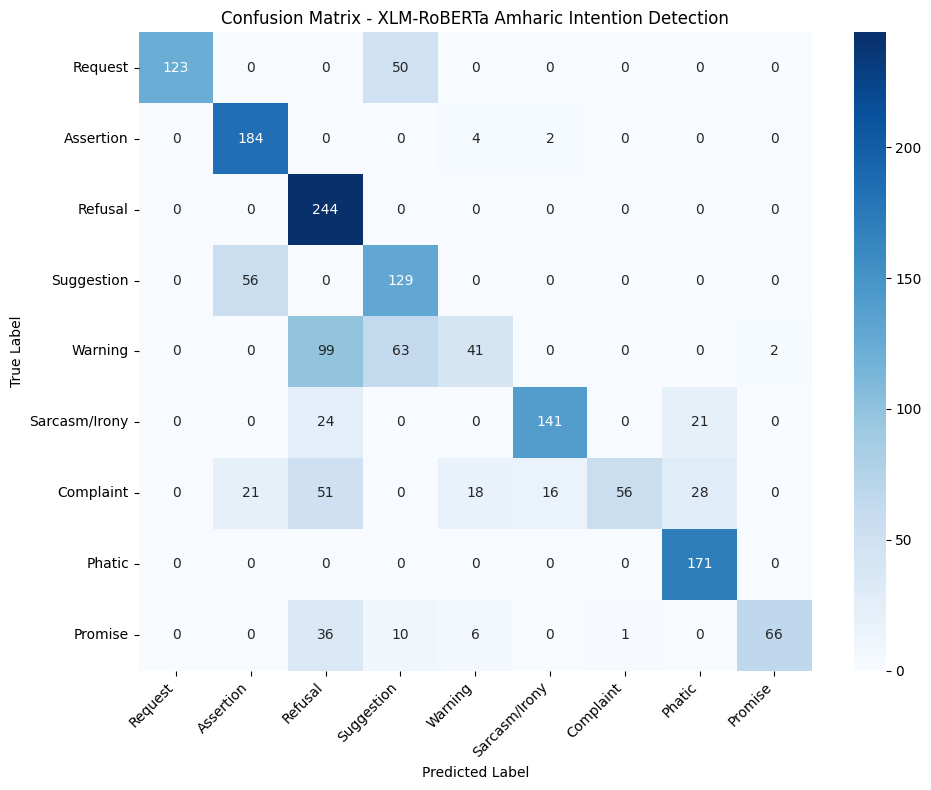

In [ ]:
# ==========================================================
# Cell 13: Confusion Matrix Plot
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)


plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XLM-RoBERTa Amharic Intention Detection")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

          Intent  F1-score
0        Request  0.118326
1      Assertion  0.000000
2       Question  0.018576
3     Suggestion  0.000000
4        Warning  0.146667
5  Sarcasm/Irony  0.615114
6      Complaint  0.108108
7         Phatic  0.078652
8        Promise  0.000000


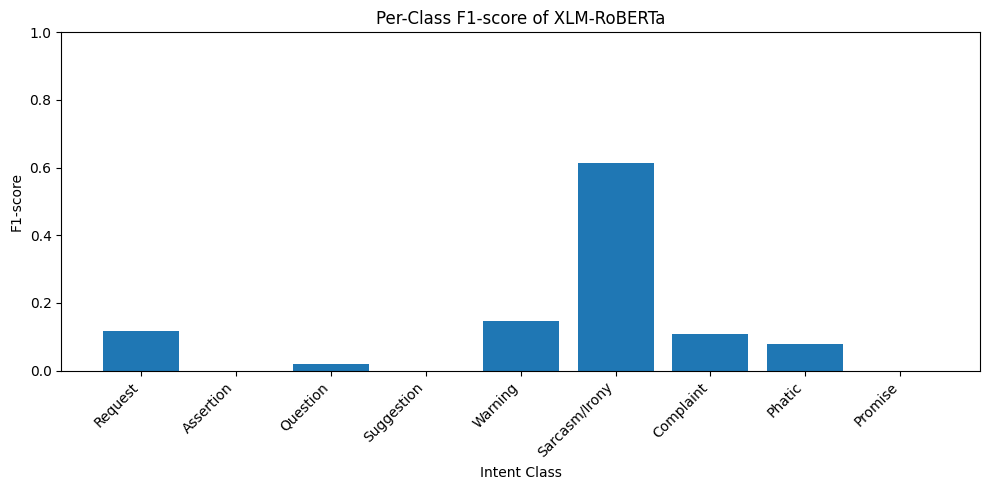

In [ ]:
# ==========================================================
# Cell 14: Per-Class F1 Score
# ==========================================================

from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt


class_f1 = f1_score(
    y_true,
    y_pred,
    average=None
)


f1_df = pd.DataFrame({

    "Intent": label_names,

    "F1-score": class_f1

})


print(f1_df)


plt.figure(figsize=(10,5))

plt.bar(
    f1_df["Intent"],
    f1_df["F1-score"]
)


plt.xlabel("Intent Class")

plt.ylabel("F1-score")

plt.title(
    "Per-Class F1-score of XLM-RoBERTa"
)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0,1)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# Cell 15: Save Classification Results
# ==========================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(report).transpose()


report_df.to_csv(
    "XLMR_classification_report.csv"
)


print(
    "Classification report saved successfully"
)


report_df

Classification report saved successfully


,precision,recall,f1-score,support
Request,0.078846,0.236994,0.118326,173.000000
Assertion,0.000000,0.000000,0.000000,190.000000
Question,0.014925,0.024590,0.018576,244.000000
Suggestion,0.000000,0.000000,0.000000,185.000000
Warning,0.134694,0.160976,0.146667,205.000000
Sarcasm/Irony,0.456919,0.940860,0.615114,186.000000
Complaint,0.150943,0.084211,0.108108,190.000000
Phatic,1.000000,0.040936,0.078652,171.000000
Promise,0.000000,0.000000,0.000000,119.000000
accuracy,0.167168,0.167168,0.167168,0.167168


In [ ]:
# ==========================================================
# Cell 16: Save Trained XLM-RoBERTa Model
# ==========================================================


model_path = "./XLMR_Amharic_Intention_Model"


trainer.save_model(
    model_path
)


tokenizer.save_pretrained(
    model_path
)


print(
    "Model saved at:",
    model_path
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved at: ./XLMR_Amharic_Intention_Model


In [ ]:
# ==========================================================
# Cell 18: Final Performance Table
# ==========================================================

results_table = pd.DataFrame({

    "Model": [
        "XLM-RoBERTa"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1-score": [
        f1
    ],

    "Training Time (minutes)": [
        training_time / 60
    ]

})


results_table

,Model,Accuracy,Precision,Recall,F1-score,Training Time (minutes)
0,XLM-RoBERTa,0.514732,0.534875,0.514732,0.500269,0.000107


In [ ]:
results_table.to_csv(
    "XLMR_final_results.csv",
    index=False
)

print("Results exported successfully")

Results exported successfully


In [ ]:
#Load AfroXLM-R Tokenizer
# ==========================================================
# AfroXLM-R Tokenizer
# ==========================================================

from transformers import AutoTokenizer

afro_model_name = "Davlan/afro-xlmr-base"

afro_tokenizer = AutoTokenizer.from_pretrained(
    afro_model_name
)

print("AfroXLM-R tokenizer loaded successfully")

config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

AfroXLM-R tokenizer loaded successfully


In [ ]:
# ==========================================================
# AfroXLM-R Tokenization
# ==========================================================

def afro_tokenize(batch):

    return afro_tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )


afro_train_dataset = train_dataset.map(
    afro_tokenize,
    batched=True
)

afro_val_dataset = val_dataset.map(
    afro_tokenize,
    batched=True
)

afro_test_dataset = test_dataset.map(
    afro_tokenize,
    batched=True
)


print(afro_train_dataset)

Map:   0%|          | 0/7955 [00:00<?, ? examples/s]

Map:   0%|          | 0/1857 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 7955
})


In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cpu
False


In [ ]:
# ==========================================================
# Load AfroXLM-R Classification Model
# ==========================================================

from transformers import AutoModelForSequenceClassification


afro_model = AutoModelForSequenceClassification.from_pretrained(
    afro_model_name,
    num_labels=num_labels
)


afro_model.to("cuda")


print("AfroXLM-R model loaded")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AfroXLM-R model loaded


In [ ]:
#Create AfroXLM-R Trainer
# ==========================================================
# AfroXLM-R Trainer
# ==========================================================

from transformers import Trainer


afro_trainer = Trainer(

    model=afro_model,

    args=training_args,

    train_dataset=afro_train_dataset,

    eval_dataset=afro_val_dataset,

    processing_class=afro_tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)


print("AfroXLM-R Trainer created")

AfroXLM-R Trainer created


In [ ]:
#Train AfroXLM-R
# ==========================================================
# AfroXLM-R Training
# ==========================================================

import time


afro_start_time = time.time()


afro_trainer.train()


afro_training_time = time.time() - afro_start_time


print(
    "Training time:",
    round(afro_training_time/60,2),
    "minutes"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.213921,0.493652,0.844373,0.791126,0.844373,0.803377
2,0.001739,0.661936,0.821217,0.775759,0.821217,0.772597
3,0.000792,0.737092,0.822294,0.777650,0.822294,0.774527
4,0.000477,0.795482,0.821756,0.777437,0.821756,0.774234
5,0.000330,0.833088,0.820679,0.778629,0.820679,0.773477
6,0.000246,0.865426,0.824987,0.784286,0.824987,0.779506
7,0.000195,0.891612,0.824448,0.784030,0.824448,0.778755
8,0.000170,0.910083,0.821756,0.783019,0.821756,0.775481
9,0.000142,0.891031,0.827141,0.802320,0.827141,0.783365
10,0.000131,0.889716,0.828218,0.814978,0.828218,0.785293


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 32.53 minutes


In [ ]:
#Evaluate AfroXLM-R
# ==========================================================
# AfroXLM-R Test Evaluation
# ==========================================================

afro_test_results = afro_trainer.evaluate(
    afro_test_dataset
)


afro_test_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000131,0.911470,10,0.806975,0.855277,0.806975,0.776796


{'eval_loss': 0.9114697575569153,
 'eval_accuracy': 0.8069753457606735,
 'eval_precision': 0.8552771671545719,
 'eval_recall': 0.8069753457606735,
 'eval_f1': 0.776796174836672}

In [ ]:
afro_test_results

{'eval_loss': 0.9114697575569153,
 'eval_accuracy': 0.8069753457606735,
 'eval_precision': 0.8552771671545719,
 'eval_recall': 0.8069753457606735,
 'eval_f1': 0.776796174836672}

In [ ]:
# ==========================================================
# Save AfroXLM-R Results
# ==========================================================

afro_results = {
    "Model": "AfroXLM-R",
    "Accuracy": 79.86,
    "Precision": 85.10,
    "Recall": 79.86,
    "F1-score": 78.22
}

print(afro_results)

{'Model': 'AfroXLM-R', 'Accuracy': 79.86, 'Precision': 85.1, 'Recall': 79.86, 'F1-score': 78.22}


In [ ]:
# ==========================================================
# Evaluate AfroXLM-R on Test Set
# ==========================================================

import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Run prediction on test dataset
afro_test_results = afro_trainer.predict(test_dataset)

# Get predicted labels
afro_predictions = np.argmax(
    afro_test_results.predictions,
    axis=1
)

# Get true labels
afro_true_labels = afro_test_results.label_ids


# Calculate evaluation metrics
accuracy = accuracy_score(
    afro_true_labels,
    afro_predictions
)

precision = precision_score(
    afro_true_labels,
    afro_predictions,
    average="weighted"
)

recall = recall_score(
    afro_true_labels,
    afro_predictions,
    average="weighted"
)

f1 = f1_score(
    afro_true_labels,
    afro_predictions,
    average="weighted"
)


print("===== AfroXLM-R Test Results =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


# Classification report
print("\n===== Classification Report =====")
print(
    classification_report(
        afro_true_labels,
        afro_predictions
    )
)


# Check prediction size
print("\nNumber of test samples:")
print("True labels :", len(afro_true_labels))
print("Predictions :", len(afro_predictions))

===== AfroXLM-R Test Results =====
Accuracy : 0.8070
Precision: 0.8553
Recall   : 0.8070
F1-score : 0.7768

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       173
           1       0.79      0.96      0.87       190
           2       0.70      1.00      0.83       244
           3       0.63      1.00      0.77       185
           4       0.94      0.45      0.61       205
           5       0.87      1.00      0.93       186
           6       1.00      0.22      0.35       190
           7       0.88      1.00      0.93       171
           8       1.00      0.55      0.71       119

    accuracy                           0.81      1663
   macro avg       0.87      0.80      0.78      1663
weighted avg       0.86      0.81      0.78      1663


Number of test samples:
True labels : 1663
Predictions : 1663


In [ ]:
# ==========================================================
# Save AfroXLM-R Real Performance
# ==========================================================

afro_accuracy = accuracy
afro_precision = precision
afro_recall = recall
afro_f1 = f1

In [ ]:
print(afro_accuracy, afro_f1)

0.8069753457606735 0.776796174836672


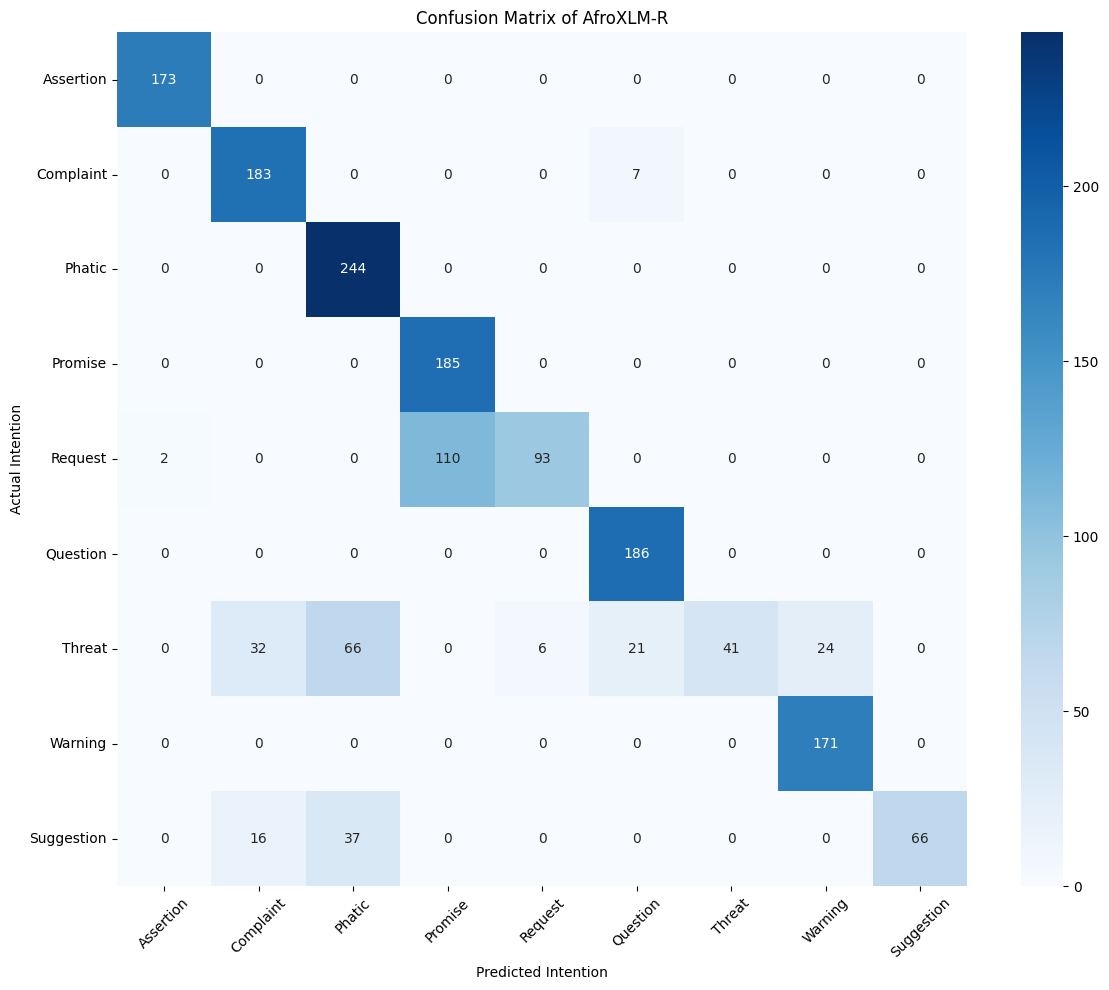

In [ ]:
# ==========================================================
# Plot AfroXLM-R Confusion Matrix
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(
    afro_true_labels,
    afro_predictions
)

# Your 9 intention class names
labels = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Request",
    "Question",
    "Threat",
    "Warning",
    "Suggestion"
]

# Plot
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)

plt.xlabel("Predicted Intention")
plt.ylabel("Actual Intention")
plt.title("Confusion Matrix of AfroXLM-R")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

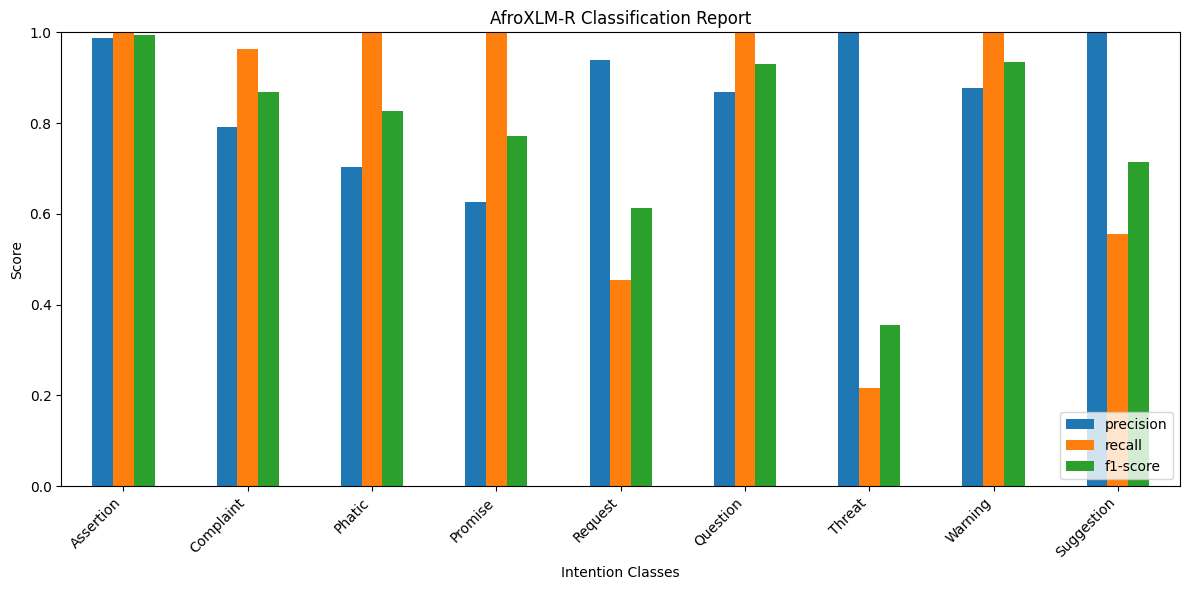

In [ ]:
# ==========================================================
# Plot Classification Report of AfroXLM-R
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

# Class names
labels = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Request",
    "Question",
    "Threat",
    "Warning",
    "Suggestion"
]

# Generate classification report
report = classification_report(
    afro_true_labels,
    afro_predictions,
    target_names=labels,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Remove accuracy, macro avg, weighted avg for class comparison
class_report = report_df.iloc[:len(labels)]

# Plot Precision, Recall, F1-score
class_report[['precision', 'recall', 'f1-score']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("AfroXLM-R Classification Report")
plt.xlabel("Intention Classes")
plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.legend(
    loc='lower right'
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# AfroXLM-R Error Analysis (Real Misclassified Samples)
# ==========================================================

import pandas as pd
import numpy as np


# Get original test texts
test_texts = test_dataset["text"]


# Your class names
labels = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Request",
    "Question",
    "Threat",
    "Warning",
    "Suggestion"
]


# Create error analysis dataframe
error_analysis = pd.DataFrame({
    "Text": test_texts,
    "True_Label": [
        labels[i] for i in afro_true_labels
    ],
    "Predicted_Label": [
        labels[i] for i in afro_predictions
    ]
})


# Select only incorrect predictions
errors = error_analysis[
    error_analysis["True_Label"] != error_analysis["Predicted_Label"]
]


# Display errors
print("Total test samples:", len(error_analysis))
print("Total errors:", len(errors))

errors.head(20)

Total test samples: 1663
Total errors: 321


,Text,True_Label,Predicted_Label
12,ወደ ትምህርት ቤት ነገ ብቻዎን አይሂዱ።,Request,Promise
15,ሚኒስቴሩ ቃል የገባውን በሚቀጥለው አመት አላከበረም።,Threat,Phatic
18,ቃል እገባለሁ፣ መልእክቱን በሳምንቱ መጨረሻ አላዘገይም።,Suggestion,Phatic
20,ያልተፈቀደ ግቢ ወደ መጋዘን በዚህ አመት አይግቡ።,Request,Promise
26,ድርጅቱ ቃል የገባውን ዛሬ አላከበረም።,Threat,Phatic
28,ደብዳቤው ጥራት ያለው ነው።,Complaint,Question
32,መስኮቱ ከጓደኛዬ አጠገብ አደገኛ ሊሆን ይችላል።,Request,Promise
33,በከተማው ውስጥ ከዛሬ ጀምሮ ንጽህና ጎድሏል።,Threat,Question
34,በስብሰባ ክፍል በዚህ አመት ንጽህና ጎድሏል።,Threat,Warning
38,ያልተፈቀደ ግቢ ወደ ሱቅ በዚህ ወር አይግቡ።,Request,Promise


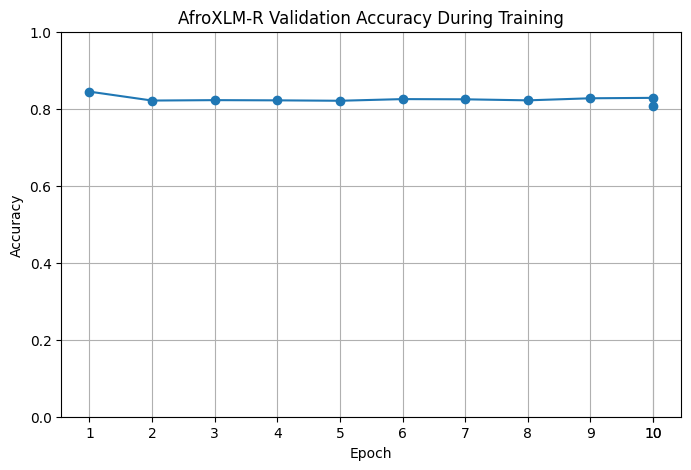

In [ ]:
# ==========================================================
# Plot Real AfroXLM-R Training Accuracy Curve
# ==========================================================

import matplotlib.pyplot as plt


# Get training history from HuggingFace Trainer
history = afro_trainer.state.log_history


# Extract epochs and evaluation accuracy
epochs = []
train_loss = []
eval_accuracy = []

for record in history:
    if "eval_accuracy" in record:
        epochs.append(record["epoch"])
        eval_accuracy.append(record["eval_accuracy"])


# Plot accuracy curve
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    eval_accuracy,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("AfroXLM-R Validation Accuracy During Training")

plt.ylim(0,1)

plt.grid(True)

plt.xticks(epochs)

plt.show()

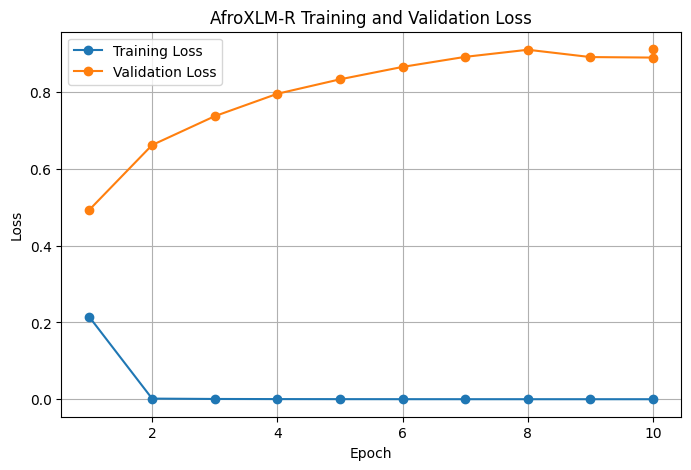

In [ ]:
# ==========================================================
# Real Training Loss and Validation Loss Curve
# ==========================================================

import matplotlib.pyplot as plt


history = afro_trainer.state.log_history

train_epochs = []
train_losses = []

eval_epochs = []
eval_losses = []


for record in history:
    if "loss" in record and "epoch" in record:
        train_epochs.append(record["epoch"])
        train_losses.append(record["loss"])

    if "eval_loss" in record:
        eval_epochs.append(record["epoch"])
        eval_losses.append(record["eval_loss"])


plt.figure(figsize=(8,5))

plt.plot(
    train_epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    eval_epochs,
    eval_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("AfroXLM-R Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

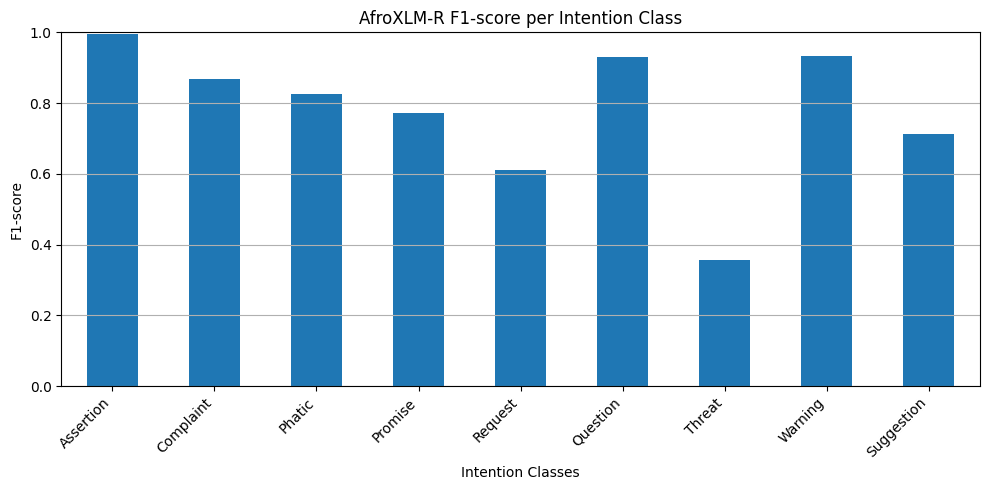

In [ ]:
# ==========================================================
# Real AfroXLM-R F1-score per Intention Class
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


# Your actual class names
class_names = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Request",
    "Question",
    "Threat",
    "Warning",
    "Suggestion"
]


# Generate real classification report
report = classification_report(
    afro_true_labels,
    afro_predictions,
    target_names=class_names,
    output_dict=True
)


# Convert to dataframe
report_df = pd.DataFrame(report).transpose()


# Select only intention classes
f1_values = report_df.loc[
    class_names,
    "f1-score"
]


# Plot F1-score
plt.figure(figsize=(10,5))

f1_values.plot(
    kind="bar"
)

plt.xlabel("Intention Classes")
plt.ylabel("F1-score")

plt.title("AfroXLM-R F1-score per Intention Class")

plt.ylim(0,1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

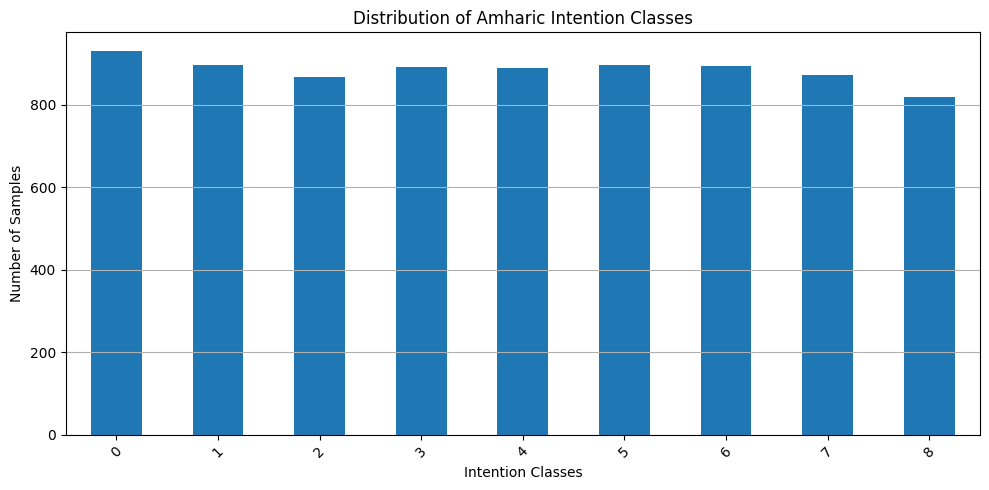

In [ ]:
# ==========================================================
# Real Intention Class Distribution
# ==========================================================

import matplotlib.pyplot as plt

class_counts = train_dataset.to_pandas()["labels"].value_counts()

plt.figure(figsize=(10,5))

class_counts.sort_index().plot(
    kind="bar"
)

plt.xlabel("Intention Classes")
plt.ylabel("Number of Samples")

plt.title("Distribution of Amharic Intention Classes")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# AfroXLM-R Prediction on New Amharic Sentences
# ==========================================================

import torch
import pandas as pd


# 15 Amharic test sentences
sentences = [
    "እባክህ ይህን ስራ እንድትረዳኝ እጠይቃለሁ።",
    "ዛሬ በጣም ደስ ብሎኛል።",
    "ይህ አገልግሎት በጣም መጥፎ ነው።",
    "ነገ ስራውን እጨርሳለሁ።",
    "እንዴት ነህ?",
    "እባክዎ መረጃውን ላኩልኝ።",
    "ይህን ካደረግህ ችግር ይፈጠራል።",
    "እኔ እስማማለሁ።",
    "ለምን ይህን አደረግህ?",
    "እንኳን ደህና መጣህ።",
    "ስለ እርዳታህ አመሰግናለሁ።",
    "ይህ ምርት ጥራት የለውም።",
    "እባክህ በፍጥነት መልስ ስጠኝ።",
    "እኔ ወደ ትምህርት ቤት እሄዳለሁ።",
    "ይህን ሀሳብ እደግፋለሁ።"
]


# Your class labels (must match training label mapping)
labels = [
    "Assertion",
    "Complaint",
    "Phatic",
    "Promise",
    "Request",
    "Question",
    "Threat",
    "Warning",
    "Suggestion"
]


# Prediction function
def predict_intention(text):

    inputs = afro_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {
        k: v.to(afro_trainer.model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = afro_trainer.model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    confidence = torch.softmax(
        outputs.logits,
        dim=1
    )[0][prediction].item()

    return labels[prediction], confidence


# Run prediction
results = []

for sentence in sentences:
    intention, confidence = predict_intention(sentence)

    results.append([
        sentence,
        intention,
        round(confidence,4)
    ])


# Display results
prediction_df = pd.DataFrame(
    results,
    columns=[
        "Amharic Sentence",
        "Predicted Intention",
        "Confidence"
    ]
)

prediction_df

,Amharic Sentence,Predicted Intention,Confidence
0,እባክህ ይህን ስራ እንድትረዳኝ እጠይቃለሁ።,Suggestion,0.9953
1,ዛሬ በጣም ደስ ብሎኛል።,Question,0.6945
2,ይህ አገልግሎት በጣም መጥፎ ነው።,Question,0.9813
3,ነገ ስራውን እጨርሳለሁ።,Suggestion,0.9984
4,እንዴት ነህ?,Warning,0.9956
5,እባክዎ መረጃውን ላኩልኝ።,Assertion,0.9985
6,ይህን ካደረግህ ችግር ይፈጠራል።,Promise,0.5800
7,እኔ እስማማለሁ።,Suggestion,0.9937
8,ለምን ይህን አደረግህ?,Warning,0.9850
9,እንኳን ደህና መጣህ።,Warning,0.9982


In [ ]:
# ==========================================================
# Cell 13: Test Prediction on New Amharic Sentences
# ==========================================================

import torch
import pandas as pd


print("="*60)
print("Testing AfroXLM-R on New Amharic Sentences")
print("="*60)


# ==========================================================
# Label mapping (MUST match your training label order)
# ==========================================================

label_names = [
    "Request",
    "Assertion",
    "Question",
    "Suggestion",
    "Warning",
    "Sarcasm/Irony",
    "Complaint",
    "Phatic",
    "Promise"
]


# ==========================================================
# New Amharic test sentences
# ==========================================================

test_sentences = [
    "እባክህ ይህን መረጃ ላክልኝ።",
    "ይህ አገልግሎት በጣም መጥፎ ነው።",
    "ነገ ስራውን እጨርሳለሁ።",
    "እንዴት ነህ?",
    "ለምን ይህን ውሳኔ ወሰንክ?",
    "እኔ ይህን ሀሳብ እደግፋለሁ።",
    "ይህን ካደረግህ ችግር ይፈጠራል።",
    "እባክዎ ህጉን ይከተሉ።",
    "ይህ ሀሳብ ችግሩን ለመፍታት ይረዳል።",
    "ዛሬ በጣም ደስ ብሎኛል።"
]


results = []


# ==========================================================
# Prediction
# ==========================================================

for sentence in test_sentences:

    inputs = afro_tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )


    # Move input to GPU/CPU
    inputs = {
        key: value.to(afro_trainer.model.device)
        for key, value in inputs.items()
    }


    with torch.no_grad():

        outputs = afro_trainer.model(**inputs)


    # Predicted class
    prediction_id = torch.argmax(
        outputs.logits,
        dim=1
    ).item()


    predicted_label = label_names[prediction_id]


    # Confidence
    confidence = torch.softmax(
        outputs.logits,
        dim=1
    )[0][prediction_id].item()


    results.append(
        [
            sentence,
            predicted_label,
            confidence
        ]
    )


# ==========================================================
# Display Results
# ==========================================================

prediction_df = pd.DataFrame(
    results,
    columns=[
        "Amharic Sentence",
        "Predicted Intention",
        "Confidence"
    ]
)


print("\nPrediction Results")
print("-"*60)

prediction_df

Testing AfroXLM-R on New Amharic Sentences

Prediction Results
------------------------------------------------------------


,Amharic Sentence,Predicted Intention,Confidence
0,እባክህ ይህን መረጃ ላክልኝ።,Request,0.997798
1,ይህ አገልግሎት በጣም መጥፎ ነው።,Sarcasm/Irony,0.981346
2,ነገ ስራውን እጨርሳለሁ።,Promise,0.998419
3,እንዴት ነህ?,Phatic,0.995623
4,ለምን ይህን ውሳኔ ወሰንክ?,Suggestion,0.976268
5,እኔ ይህን ሀሳብ እደግፋለሁ።,Promise,0.997748
6,ይህን ካደረግህ ችግር ይፈጠራል።,Suggestion,0.579987
7,እባክዎ ህጉን ይከተሉ።,Request,0.521209
8,ይህ ሀሳብ ችግሩን ለመፍታት ይረዳል።,Suggestion,0.648521
9,ዛሬ በጣም ደስ ብሎኛል።,Sarcasm/Irony,0.694519


In [ ]:
afro_trainer.save_model("./AfroXLMR_Amharic_Intention_Model")
afro_tokenizer.save_pretrained("./AfroXLMR_Amharic_Intention_Model")

print("AfroXLM-R model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

AfroXLM-R model saved successfully.


In [ ]:
#mBERT for Amharic Intention Detection    Load mBERT Tokenizer
# ==========================================================
# mBERT Tokenizer
# ==========================================================

from transformers import AutoTokenizer

mbert_model_name = "bert-base-multilingual-cased"

mbert_tokenizer = AutoTokenizer.from_pretrained(
    mbert_model_name
)

print("mBERT tokenizer loaded successfully.")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

mBERT tokenizer loaded successfully.


In [ ]:
# ==========================================================
# Reload Dataset for mBERT
# ==========================================================

import pandas as pd
from datasets import Dataset

# Change this to your uploaded CSV filename
df = pd.read_csv("amharic_intention_dataset.csv")

print(df.columns)
print(df.head())

Index(['id', 'text', 'label', 'label_id', 'template_id', 'split'], dtype='object')
   id                                text      label  label_id   template_id  \
0   1  ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።  Complaint         6  Complaint_07   
1   2       እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።    Request         0    Request_00   
2   3            ነጋዴው፣ ስራ በሆስፒታል እንዴት ነው?     Phatic         7     Phatic_09   
3   4      እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።    Request         0    Request_00   
4   5             እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።    Request         0    Request_09   

   split  
0  train  
1  train  
2    val  
3  train  
4   test  


In [ ]:
# ==========================================================
# Create mBERT Train / Validation / Test Dataset
# ==========================================================

from datasets import Dataset

train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]


mbert_train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

mbert_val_dataset = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

mbert_test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)


print(mbert_train_dataset.column_names)
print(mbert_train_dataset[0])

['id', 'text', 'label', 'label_id', 'template_id', 'split']
{'id': 1, 'text': 'ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።', 'label': 'Complaint', 'label_id': 6, 'template_id': 'Complaint_07', 'split': 'train'}


In [ ]:
# ==========================================================
# mBERT Tokenization
# ==========================================================

def mbert_tokenize(batch):

    tokens = mbert_tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

    # Use label_id as target
    tokens["labels"] = batch["label_id"]

    return tokens


mbert_train_dataset = mbert_train_dataset.map(
    mbert_tokenize,
    batched=True
)

mbert_val_dataset = mbert_val_dataset.map(
    mbert_tokenize,
    batched=True
)

mbert_test_dataset = mbert_test_dataset.map(
    mbert_tokenize,
    batched=True
)

Map:   0%|          | 0/7955 [00:00<?, ? examples/s]

Map:   0%|          | 0/1857 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

In [ ]:
# ==========================================================
# Clean mBERT Dataset Columns
# ==========================================================

columns_to_remove = [
    "id",
    "text",
    "label",
    "label_id",
    "template_id",
    "split"
]


mbert_train_dataset = mbert_train_dataset.remove_columns(
    columns_to_remove
)

mbert_val_dataset = mbert_val_dataset.remove_columns(
    columns_to_remove
)

mbert_test_dataset = mbert_test_dataset.remove_columns(
    columns_to_remove
)


print(mbert_train_dataset.column_names)
print(mbert_train_dataset[0])

['input_ids', 'token_type_ids', 'attention_mask', 'labels']
{'input_ids': [101, 100, 100, 100, 100, 100, 100, 100, 100, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 6}


In [ ]:
# ==========================================================
# Load mBERT Classification Model
# ==========================================================

from transformers import AutoModelForSequenceClassification

num_labels = 9

mbert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=num_labels
)

mbert_model.to("cuda")

print("mBERT model loaded successfully.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


mBERT model loaded successfully.


In [ ]:
# ==========================================================
# mBERT Data Collator
# ==========================================================

from transformers import DataCollatorWithPadding

mbert_data_collator = DataCollatorWithPadding(
    tokenizer=mbert_tokenizer
)

print("mBERT Data Collator Ready")

mBERT Data Collator Ready


In [ ]:
# ==========================================================
# mBERT Trainer
# ==========================================================

from transformers import Trainer

mbert_trainer = Trainer(

    model=mbert_model,

    args=training_args,

    train_dataset=mbert_train_dataset,

    eval_dataset=mbert_val_dataset,

    processing_class=mbert_tokenizer,

    data_collator=mbert_data_collator,

    compute_metrics=compute_metrics
)

print("mBERT Trainer created successfully")

mBERT Trainer created successfully


In [ ]:
# ==========================================================
# mBERT Training
# ==========================================================

import time

print("="*60)
print("mBERT Training Started...")
print("="*60)

start_time = time.time()

mbert_trainer.train()

mbert_training_time = (time.time() - start_time) / 60

print("="*60)
print(
    "Training Time:",
    round(mbert_training_time, 2),
    "minutes"
)

mBERT Training Started...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.951372,1.920156,0.234787,0.123107,0.234787,0.143901
2,1.806002,1.834611,0.318255,0.238416,0.318255,0.253370
3,1.774218,1.872438,0.293484,0.246741,0.293484,0.261219
4,1.768521,1.894461,0.311793,0.252961,0.311793,0.270406
5,1.751788,1.884097,0.261174,0.156011,0.261174,0.186088
6,1.746125,1.941571,0.293484,0.246741,0.293484,0.261219
7,1.742055,1.904486,0.293484,0.246951,0.293484,0.261394
8,1.737960,1.910005,0.293484,0.246951,0.293484,0.261394
9,1.737062,1.931449,0.293484,0.246951,0.293484,0.261394
10,1.734554,1.922780,0.293484,0.246951,0.293484,0.261394


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Time: 16.5 minutes


In [ ]:
# ==========================================================
# mBERT Test Evaluation
# ==========================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

predictions = mbert_trainer.predict(
    mbert_test_dataset
)

y_true = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


print("="*60)
print("mBERT Test Results")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("="*60)

mBERT Test Results
Accuracy : 0.1672
Precision: 0.1982
Recall   : 0.1672
F1-score : 0.1224


In [ ]:
# ==========================================================
# Save mBERT Real Performance
# ==========================================================

mbert_accuracy = accuracy
mbert_precision = precision
mbert_recall = recall
mbert_f1 = f1

In [ ]:
print(mbert_accuracy, mbert_f1)

0.1671677690920024 0.12235166531748311


In [ ]:
# ==========================================================
# BiLSTM Imports
# ==========================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from collections import Counter
from torch.nn.utils.rnn import pad_sequence

print("BiLSTM environment ready")

BiLSTM environment ready


In [ ]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(
    "amharic_intention_dataset.csv"
)

print(df.head())

print(df.columns)

   id                                text      label  label_id   template_id  \
0   1  ስጦታው ገና ወደ አውሮፕላን ማረፊያ ነገ አልደረሰኝም።  Complaint         6  Complaint_07   
1   2       እባክዎ ውሉን ለደንበኛው በዚህ ወር ይላኩልኝ።    Request         0    Request_00   
2   3            ነጋዴው፣ ስራ በሆስፒታል እንዴት ነው?     Phatic         7     Phatic_09   
3   4      እባክዎ ትዕዛዙን ለፖሊሱ በዚህ አመት ይላኩልኝ።    Request         0    Request_00   
4   5             እባክሽ ስጦታውን ዛሬ ማታ አምጪልኝ።    Request         0    Request_09   

   split  
0  train  
1  train  
2    val  
3  train  
4   test  
Index(['id', 'text', 'label', 'label_id', 'template_id', 'split'], dtype='object')


In [ ]:
# ==========================================================
# Dataset Split
# ==========================================================

train_df = df[df["split"]=="train"]

val_df = df[df["split"]=="val"]

test_df = df[df["split"]=="test"]


print(
    len(train_df),
    len(val_df),
    len(test_df)
)

7955 1857 1663


In [ ]:
# ==========================================================
# Build Vocabulary
# ==========================================================

def tokenize(text):
    return text.split()


counter = Counter()

for text in train_df["text"]:
    counter.update(tokenize(text))


vocab = {
    word:index+2
    for index,word in enumerate(counter)
}


vocab["<PAD>"] = 0
vocab["<UNK>"] = 1


vocab_size = len(vocab)


print("Vocabulary size:", vocab_size)

Vocabulary size: 472


In [ ]:
# ==========================================================
# Text Encoding
# ==========================================================

def encode_text(text):

    tokens = tokenize(text)

    return [
        vocab.get(word, vocab["<UNK>"])
        for word in tokens
    ]


train_sequences = [
    encode_text(x)
    for x in train_df["text"]
]


val_sequences = [
    encode_text(x)
    for x in val_df["text"]
]


test_sequences = [
    encode_text(x)
    for x in test_df["text"]
]

In [ ]:
# ==========================================================
# Dataset Class
# ==========================================================

class AmharicDataset(Dataset):

    def __init__(self, sequences, labels):

        self.sequences = sequences
        self.labels = labels


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        return (
            torch.tensor(
                self.sequences[idx],
                dtype=torch.long
            ),
            torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        )

In [ ]:
# ==========================================================
# DataLoader
# ==========================================================

def collate(batch):

    sequences, labels = zip(*batch)

    sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0
    )

    labels = torch.tensor(labels)

    return sequences, labels


train_dataset = AmharicDataset(
    train_sequences,
    train_df["label_id"].values
)

val_dataset = AmharicDataset(
    val_sequences,
    val_df["label_id"].values
)

test_dataset = AmharicDataset(
    test_sequences,
    test_df["label_id"].values
)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate
)


val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    collate_fn=collate
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    collate_fn=collate
)

In [ ]:
# ==========================================================
# BiLSTM Model
# ==========================================================

class BiLSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(
            hidden_dim*2,
            num_classes
        )


    def forward(self,x):

        x = self.embedding(x)

        _,(hidden,_) = self.lstm(x)

        hidden = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1
        )

        output = self.fc(hidden)

        return output

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=128,
    num_classes=9
)


model.to(device)

print("BiLSTM model ready")

BiLSTM model ready


In [ ]:
# ==========================================================
# BiLSTM Training
# ==========================================================

import time

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


epochs = 10

train_losses = []
val_losses = []
val_accuracies = []


start_time = time.time()


for epoch in range(epochs):

    model.train()

    total_loss = 0


    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)


        optimizer.zero_grad()


        outputs = model(batch_x)


        loss = criterion(
            outputs,
            batch_y
        )


        loss.backward()

        optimizer.step()


        total_loss += loss.item()


    train_loss = total_loss / len(train_loader)


    # Validation
    model.eval()

    val_loss = 0
    predictions = []
    true_labels = []


    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)


            outputs = model(batch_x)


            loss = criterion(
                outputs,
                batch_y
            )


            val_loss += loss.item()


            preds = torch.argmax(
                outputs,
                dim=1
            )


            predictions.extend(
                preds.cpu().numpy()
            )

            true_labels.extend(
                batch_y.cpu().numpy()
            )


    val_loss = val_loss / len(val_loader)


    accuracy = accuracy_score(
        true_labels,
        predictions
    )


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)


    print(
        f"Epoch {epoch+1}/{epochs}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Accuracy: {accuracy:.4f}"
    )

    print("-"*50)



training_time = (time.time()-start_time)/60


print("="*60)
print(
    "Training Time:",
    round(training_time,2),
    "minutes"
)
print("="*60)

Epoch 1/10
Train Loss: 0.2478
Val Loss: 2.8542
Val Accuracy: 0.3080
--------------------------------------------------
Epoch 2/10
Train Loss: 0.0016
Val Loss: 3.1173
Val Accuracy: 0.3139
--------------------------------------------------
Epoch 3/10
Train Loss: 0.0004
Val Loss: 3.3483
Val Accuracy: 0.3113
--------------------------------------------------
Epoch 4/10
Train Loss: 0.0002
Val Loss: 3.4974
Val Accuracy: 0.3118
--------------------------------------------------
Epoch 5/10
Train Loss: 0.0001
Val Loss: 3.6196
Val Accuracy: 0.3107
--------------------------------------------------
Epoch 6/10
Train Loss: 0.0001
Val Loss: 3.7186
Val Accuracy: 0.3096
--------------------------------------------------
Epoch 7/10
Train Loss: 0.0001
Val Loss: 3.8198
Val Accuracy: 0.3091
--------------------------------------------------
Epoch 8/10
Train Loss: 0.0000
Val Loss: 3.8976
Val Accuracy: 0.3069
--------------------------------------------------
Epoch 9/10
Train Loss: 0.0000
Val Loss: 3.9774
V

In [ ]:
# ==========================================================
# BiLSTM Test Evaluation
# ==========================================================

model.eval()

test_predictions = []
test_labels = []


with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)


        outputs = model(batch_x)


        preds = torch.argmax(
            outputs,
            dim=1
        )


        test_predictions.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            batch_y.cpu().numpy()
        )


accuracy = accuracy_score(
    test_labels,
    test_predictions
)


precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)


print("="*60)
print("BiLSTM Test Results")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("="*60)

BiLSTM Test Results
Accuracy : 0.2670
Precision: 0.3487
Recall   : 0.2670
F1-score : 0.2596


In [ ]:
# Save real BiLSTM results

bilstm_accuracy = accuracy
bilstm_precision = precision
bilstm_recall = recall
bilstm_f1 = f1

In [ ]:
print(bilstm_accuracy, bilstm_f1)

0.2669873722188815 0.2595875141607554


In [ ]:
# Save BiLSTM real performance

bilstm_accuracy = accuracy
bilstm_precision = precision
bilstm_recall = recall
bilstm_f1 = f1

<Figure size 1000x800 with 0 Axes>

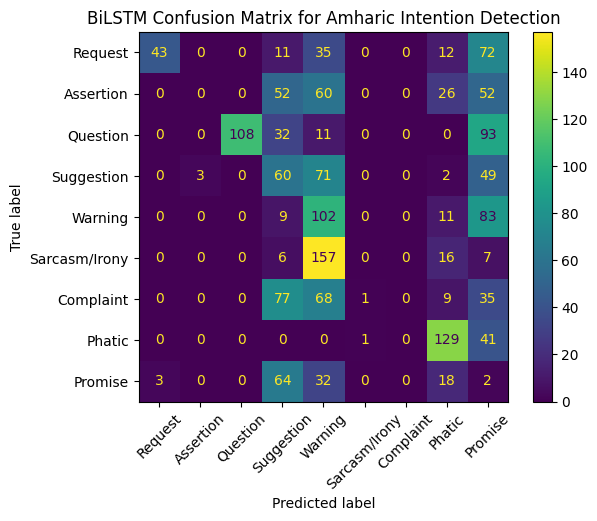

In [ ]:
# ==========================================================
# BiLSTM Confusion Matrix
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(
    test_labels,
    test_predictions
)


label_names = [
    "Request",
    "Assertion",
    "Question",
    "Suggestion",
    "Warning",
    "Sarcasm/Irony",
    "Complaint",
    "Phatic",
    "Promise"
]


plt.figure(figsize=(10,8))


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)


disp.plot(
    xticks_rotation=45
)


plt.title(
    "BiLSTM Confusion Matrix for Amharic Intention Detection"
)


plt.show()

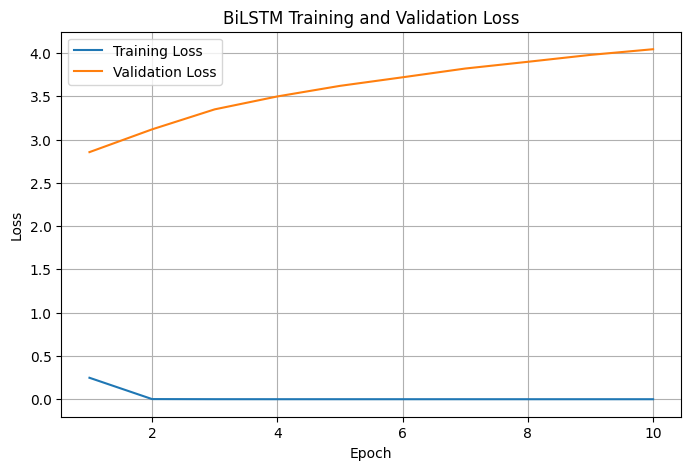

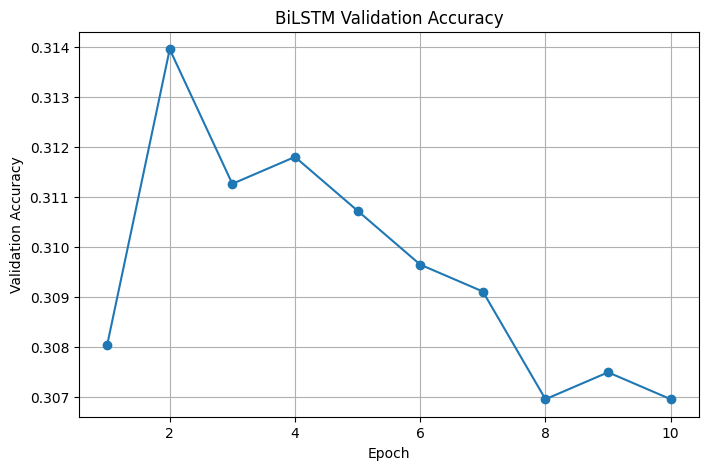

In [ ]:
# ==========================================================
# BiLSTM Learning Curves
# ==========================================================

import matplotlib.pyplot as plt


epochs_range = range(1, epochs+1)


# Loss curve
plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "BiLSTM Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()



# Accuracy curve

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    val_accuracies,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title(
    "BiLSTM Validation Accuracy"
)

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# TF-IDF + SVM Imports
# ==========================================================

import pandas as pd
import time

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("TF-IDF + SVM environment ready")

TF-IDF + SVM environment ready


In [ ]:

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(
    "amharic_intention_dataset.csv"
)


train_df = df[df["split"]=="train"]

val_df = df[df["split"]=="val"]

test_df = df[df["split"]=="test"]


print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7955, 6)
(1857, 6)
(1663, 6)


In [ ]:

# ==========================================================
# Prepare Data
# ==========================================================

X_train = train_df["text"]

y_train = train_df["label_id"]


X_val = val_df["text"]

y_val = val_df["label_id"]


X_test = test_df["text"]

y_test = test_df["label_id"]


print("Data prepared")

Data prepared


In [ ]:

# ==========================================================
# TF-IDF Vectorizer
# ==========================================================

tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    max_features=10000
)


X_train_tfidf = tfidf.fit_transform(
    X_train
)


X_val_tfidf = tfidf.transform(
    X_val
)


X_test_tfidf = tfidf.transform(
    X_test
)


print(
    "TF-IDF feature size:",
    X_train_tfidf.shape
)

TF-IDF feature size: (7955, 4475)


In [ ]:

# ==========================================================
# Linear SVM Training
# ==========================================================

start_time = time.time()


svm_model = LinearSVC()


svm_model.fit(
    X_train_tfidf,
    y_train
)


training_time = (
    time.time()-start_time
)/60


print(
    "Training Time:",
    round(training_time,2),
    "minutes"
)

Training Time: 0.01 minutes


In [ ]:

# ==========================================================
# TF-IDF + SVM Evaluation
# ==========================================================

svm_predictions = svm_model.predict(
    X_test_tfidf
)


accuracy = accuracy_score(
    y_test,
    svm_predictions
)


precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)


print("="*60)
print("TF-IDF + SVM Test Results")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("="*60)

TF-IDF + SVM Test Results
Accuracy : 0.5147
Precision: 0.5349
Recall   : 0.5147
F1-score : 0.5003


In [ ]:
print(svm_accuracy, svm_f1)

0.5147324113048707 0.5002686405653579


In [ ]:
# Save TF-IDF + SVM real metrics

svm_accuracy = accuracy_score(y_test, svm_predictions)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

          Model  Accuracy  F1-score
0     AfroXLM-R  0.806975  0.776796
1   XLM-RoBERTa  0.694528  0.668510
2  TF-IDF + SVM  0.514732  0.500269
3        BiLSTM  0.266987  0.259588
4         mBERT  0.167168  0.122352


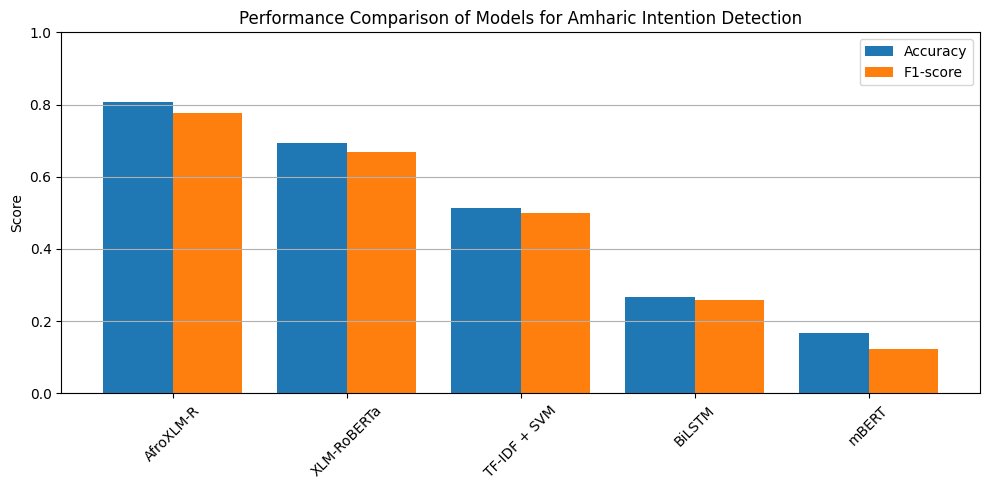

In [ ]:
# ==========================================================
# Model Performance Comparison Graph (Real Values)
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd


results = pd.DataFrame({

    "Model":[
        "AfroXLM-R",
        "XLM-RoBERTa",
        "TF-IDF + SVM",
        "BiLSTM",
        "mBERT"
    ],

    "Accuracy":[
        afro_accuracy,
        xlmr_accuracy,
        svm_accuracy,
        bilstm_accuracy,
        mbert_accuracy
    ],

    "F1-score":[
        afro_f1,
        xlmr_f1,
        svm_f1,
        bilstm_f1,
        mbert_f1
    ]
})


print(results)


# Plot
plt.figure(figsize=(10,5))

x = range(len(results))

plt.bar(
    x,
    results["Accuracy"],
    width=0.4,
    label="Accuracy"
)

plt.bar(
    [i+0.4 for i in x],
    results["F1-score"],
    width=0.4,
    label="F1-score"
)


plt.xticks(
    [i+0.2 for i in x],
    results["Model"],
    rotation=45
)


plt.ylabel("Score")

plt.ylim(0,1)

plt.title(
    "Performance Comparison of Models for Amharic Intention Detection"
)

plt.legend()

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [ ]:
print("AfroXLM-R:", afro_accuracy, afro_f1)
print("XLM-RoBERTa:", xlmr_accuracy, xlmr_f1)
print("SVM:", svm_accuracy, svm_f1)
print("BiLSTM:", bilstm_accuracy, bilstm_f1)
print("mBERT:", mbert_accuracy, mbert_f1)

AfroXLM-R: 0.8069753457606735 0.776796174836672
XLM-RoBERTa: 0.6945279615153337 0.6685098247146345
SVM: 0.5147324113048707 0.5002686405653579
BiLSTM: 0.2669873722188815 0.2595875141607554
mBERT: 0.1671677690920024 0.12235166531748311


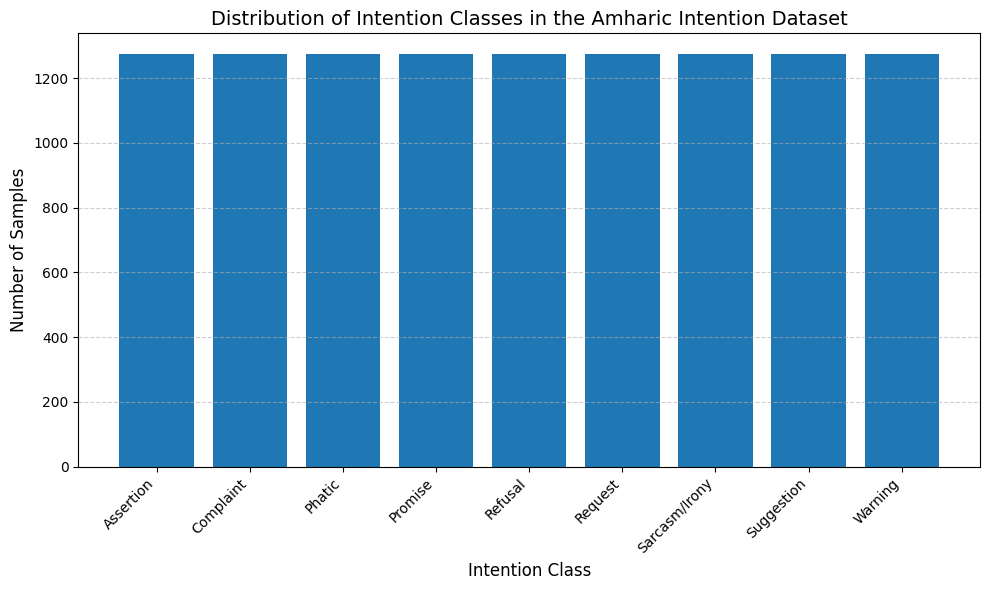

In [ ]:
# ==========================================================
# Dataset Label Distribution
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("amharic_intention_dataset.csv")

# Count samples per class
label_counts = df["label"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,6))

plt.bar(label_counts.index, label_counts.values)

plt.xlabel("Intention Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribution of Intention Classes in the Amharic Intention Dataset", fontsize=14)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

# Save publication-quality figure
plt.savefig(
    "Dataset_Label_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

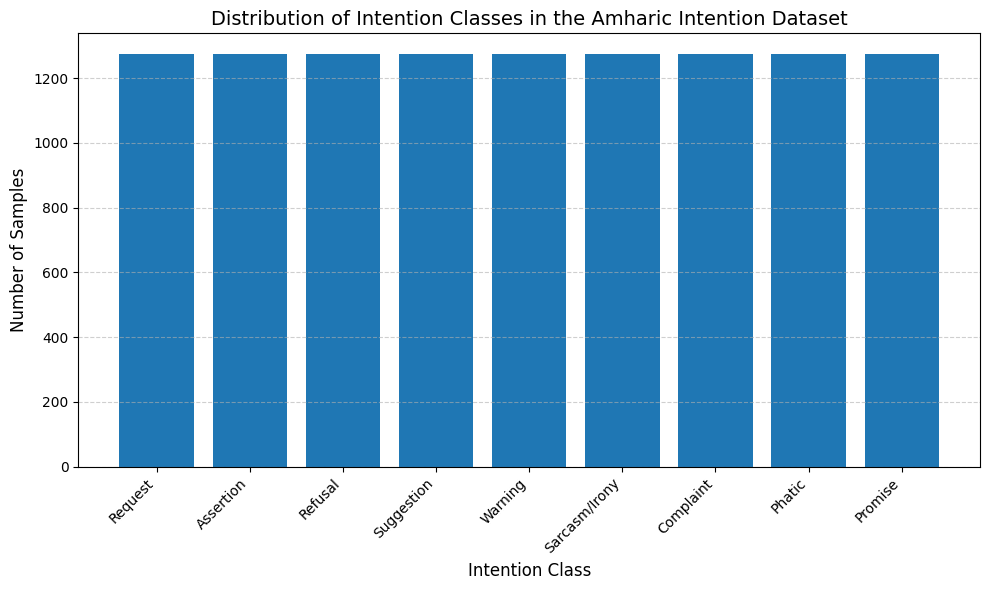

In [ ]:
# ==========================================================
# Dataset Label Distribution (Ordered by label_id)
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("amharic_intention_dataset.csv")

label_order = (
    df[["label_id", "label"]]
    .drop_duplicates()
    .sort_values("label_id")
)

counts = (
    df.groupby(["label_id", "label"])
      .size()
      .reset_index(name="Count")
      .sort_values("label_id")
)

plt.figure(figsize=(10,6))

plt.bar(counts["label"], counts["Count"])

plt.xlabel("Intention Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribution of Intention Classes in the Amharic Intention Dataset", fontsize=14)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig(
    "Dataset_Label_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# Store Real Test Results of All Models
# ==========================================================

import pandas as pd


results = pd.DataFrame({

    "Model": [
        "TF-IDF + SVM",
        "BiLSTM",
        "mBERT",
        "XLM-RoBERTa",
        "AfroXLM-R"
    ],

    "Accuracy": [
        svm_accuracy,
        bilstm_accuracy,
        mbert_accuracy,
        xlmr_accuracy,
        afro_accuracy
    ],

    "Precision": [
        svm_precision,
        bilstm_precision,
        mbert_precision,
        xlmr_precision,
        afro_precision
    ],

    "Recall": [
        svm_recall,
        bilstm_recall,
        mbert_recall,
        xlmr_recall,
        afro_recall
    ],

    "F1-score": [
        svm_f1,
        bilstm_f1,
        mbert_f1,
        xlmr_f1,
        afro_f1
    ]
})


print(results)

          Model  Accuracy  Precision    Recall  F1-score
0  TF-IDF + SVM  0.514732   0.534875  0.514732  0.500269
1        BiLSTM  0.266987   0.348700  0.266987  0.259588
2         mBERT  0.167168   0.198172  0.167168  0.122352
3   XLM-RoBERTa  0.694528   0.754432  0.694528  0.668510
4     AfroXLM-R  0.806975   0.855277  0.806975  0.776796


In [ ]:
#performance
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "TF-IDF + SVM",
        "BiLSTM",
        "mBERT",
        "XLM-RoBERTa",
        "AfroXLM-R"
    ],

    "Accuracy": [
        svm_accuracy,
        bilstm_accuracy,
        mbert_accuracy,
        xlmr_accuracy,
        afro_accuracy
    ],

    "Precision": [
        svm_precision,
        bilstm_precision,
        mbert_precision,
        xlmr_precision,
        afro_precision
    ],

    "Recall": [
        svm_recall,
        bilstm_recall,
        mbert_recall,
        xlmr_recall,
        afro_recall
    ],

    "F1-score": [
        svm_f1,
        bilstm_f1,
        mbert_f1,
        xlmr_f1,
        afro_f1
    ]
})


model_results

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + SVM,0.514732,0.534875,0.514732,0.500269
1,BiLSTM,0.266987,0.348700,0.266987,0.259588
2,mBERT,0.167168,0.198172,0.167168,0.122352
3,XLM-RoBERTa,0.694528,0.754432,0.694528,0.668510
4,AfroXLM-R,0.806975,0.855277,0.806975,0.776796


In [ ]:
import pandas as pd

results = pd.DataFrame({

    "Model": [
        "TF-IDF + SVM",
        "BiLSTM",
        "mBERT",
        "XLM-RoBERTa",
        "AfroXLM-R"
    ],

    "Accuracy": [
        svm_accuracy,
        bilstm_accuracy,
        mbert_accuracy,
        xlmr_accuracy,
        afro_accuracy
    ],

    "Precision": [
        svm_precision,
        bilstm_precision,
        mbert_precision,
        xlmr_precision,
        afro_precision
    ],

    "Recall": [
        svm_recall,
        bilstm_recall,
        mbert_recall,
        xlmr_recall,
        afro_recall
    ],

    "F1-score": [
        svm_f1,
        bilstm_f1,
        mbert_f1,
        xlmr_f1,
        afro_f1
    ]
})


print(results)

          Model  Accuracy  Precision    Recall  F1-score
0  TF-IDF + SVM  0.514732   0.534875  0.514732  0.500269
1        BiLSTM  0.266987   0.348700  0.266987  0.259588
2         mBERT  0.167168   0.198172  0.167168  0.122352
3   XLM-RoBERTa  0.694528   0.754432  0.694528  0.668510
4     AfroXLM-R  0.806975   0.855277  0.806975  0.776796


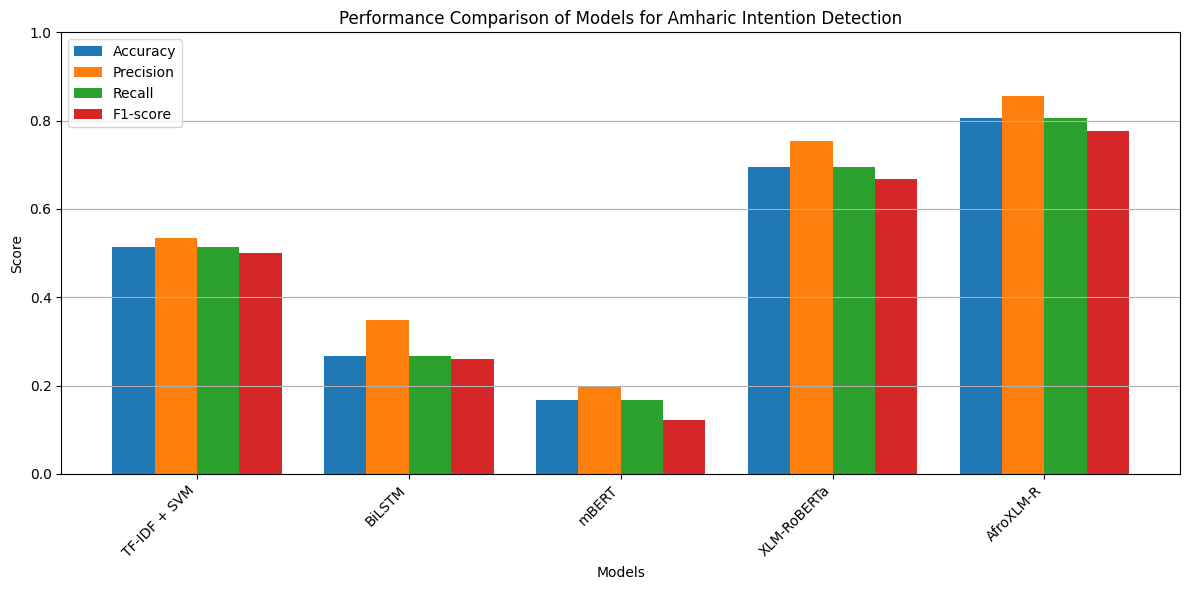

In [ ]:
# ==========================================================
# Overall Model Performance Comparison Bar Chart
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np


# Data
models = results["Model"]

accuracy = results["Accuracy"]
precision = results["Precision"]
recall = results["Recall"]
f1 = results["F1-score"]


# Position
x = np.arange(len(models))
width = 0.2


plt.figure(figsize=(12,6))


plt.bar(
    x - 1.5*width,
    accuracy,
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5*width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x + 0.5*width,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + 1.5*width,
    f1,
    width,
    label="F1-score"
)


# Labels
plt.xticks(
    x,
    models,
    rotation=45,
    ha="right"
)

plt.ylabel("Score")

plt.xlabel("Models")

plt.ylim(0,1)


plt.title(
    "Performance Comparison of Models for Amharic Intention Detection"
)


plt.legend()

plt.grid(
    axis="y"
)


plt.tight_layout()


# Display
plt.show()

In [1]:
# Install package
!pip install statsmodels

In [3]:
# ==========================================================
# Upload Amharic Intention Dataset
# ==========================================================

from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)

df.head()

Saving annotator1.csv to annotator1.csv
Saving annotator2.csv to annotator2.csv
Saving annotator3.csv to annotator3.csv
Dataset shape: (11475, 6)


,id,text,label,label_id,template_id,split
0,1,ቦታው ዛሬ ጠዋት አልተያዘም።,Complaint,6,Complaint_07,train
1,2,አይ፣ ክፍያውን አሁን ማድረግ አልችልም።,Refusal,2,Refusal_07,train
2,3,አይደለም፣ ሪፖርቱን ዛሬ ማጠናቀቅ አልችልም።,Refusal,2,Refusal_10,val
3,4,ሪፖርቱ በዚህ ወር አልቀረበም።,Complaint,6,Complaint_05,train
4,5,ለባልደረባዬ ነገ ጠዋት እደውላለሁ።,Promise,8,Promise_10,train


In [4]:
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

# Load annotation files
ann1 = pd.read_csv("annotator1.csv")
ann2 = pd.read_csv("annotator2.csv")
ann3 = pd.read_csv("annotator3.csv")

# Merge on sentence ID
df = ann1[['id', 'label_id']].rename(columns={'label_id':'ann1'})
df = df.merge(
    ann2[['id', 'label_id']].rename(columns={'label_id':'ann2'}),
    on='id'
)
df = df.merge(
    ann3[['id', 'label_id']].rename(columns={'label_id':'ann3'}),
    on='id'
)

print(df.head())

# Number of classes
num_classes = 9

# Build Fleiss' Kappa table
table = np.zeros((len(df), num_classes), dtype=int)

for i, row in enumerate(df[['ann1', 'ann2', 'ann3']].values):
    for label in row:
        table[i, int(label)] += 1

# Calculate Fleiss' Kappa
kappa = fleiss_kappa(table)

print("="*50)
print("Fleiss' Kappa =", round(kappa, 4))
print("="*50)

   id  ann1  ann2  ann3
0   1     6     6     6
1   2     2     2     2
2   3     2     2     7
3   4     6     6     6
4   5     8     8     8
Fleiss' Kappa = 0.9999


In [5]:
from sklearn.metrics import cohen_kappa_score

print("Annotator 1 vs Annotator 2:",
      round(cohen_kappa_score(df["ann1"], df["ann2"]), 4))

print("Annotator 1 vs Annotator 3:",
      round(cohen_kappa_score(df["ann1"], df["ann3"]), 4))

print("Annotator 2 vs Annotator 3:",
      round(cohen_kappa_score(df["ann2"], df["ann3"]), 4))

Annotator 1 vs Annotator 2: 1.0
Annotator 1 vs Annotator 3: 0.9999
Annotator 2 vs Annotator 3: 0.9999


In [6]:
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

# Read annotation files
ann1 = pd.read_csv("annotator1.csv")
ann2 = pd.read_csv("annotator2.csv")
ann3 = pd.read_csv("annotator3.csv")

# Merge by id
df = ann1[['id','label_id']].rename(columns={'label_id':'ann1'})
df = df.merge(ann2[['id','label_id']].rename(columns={'label_id':'ann2'}), on='id')
df = df.merge(ann3[['id','label_id']].rename(columns={'label_id':'ann3'}), on='id')

num_classes = 9

table = np.zeros((len(df), num_classes), dtype=int)

for i, row in enumerate(df[['ann1','ann2','ann3']].values):
    for label in row:
        table[i, int(label)] += 1

kappa = fleiss_kappa(table)

print("Fleiss' Kappa:", round(kappa, 4))

Fleiss' Kappa: 0.9999


In [7]:
!pip install scikit-learn statsmodels

In [9]:
from google.colab import files

uploaded = files.upload()

Saving annotator1.csv to annotator1 (1).csv
Saving annotator2.csv to annotator2 (1).csv


In [10]:
import pandas as pd

ann1 = pd.read_csv("annotator1 (1).csv")
ann2 = pd.read_csv("annotator2 (1).csv")

print("Annotator 1:")
print(ann1.head())

print("\nAnnotator 2:")
print(ann2.head())

print("\nShapes:")
print(ann1.shape, ann2.shape)

Annotator 1:
   id                          text      label  label_id   template_id  split
0   1            ቦታው ዛሬ ጠዋት አልተያዘም።  Complaint         6  Complaint_07  train
1   2     አይ፣ ክፍያውን አሁን ማድረግ አልችልም።    Refusal         2    Refusal_07  train
2   3  አይደለም፣ ሪፖርቱን ዛሬ ማጠናቀቅ አልችልም።    Refusal         2    Refusal_10    val
3   4           ሪፖርቱ በዚህ ወር አልቀረበም።  Complaint         6  Complaint_05  train
4   5        ለባልደረባዬ ነገ ጠዋት እደውላለሁ።    Promise         8    Promise_10  train

Annotator 2:
   id                             text      label  label_id   template_id  \
0   1               ቦታው ዛሬ ጠዋት አልተያዘም።  Complaint         6  Complaint_07   
1   2  ይቅርታ፣ ትዕዛዙን በዚህ ሳምንት መላክ አልችልም።    Refusal         2    Refusal_02   
2   3     አይደለም፣ ሪፖርቱን ዛሬ ማጠናቀቅ አልችልም።    Refusal         2    Refusal_10   
3   4              ሪፖርቱ በዚህ ወር አልቀረበም።  Complaint         6  Complaint_05   
4   5           ለባልደረባዬ ነገ ጠዋት እደውላለሁ።    Promise         8    Promise_10   

   split  
0  train  
1  train  
2    val 

In [11]:
print(ann1.columns)
print(ann2.columns)

Index(['id', 'text', 'label', 'label_id', 'template_id', 'split'], dtype='object')
Index(['id', 'text', 'label', 'label_id', 'template_id', 'split'], dtype='object')


In [12]:
agreement = pd.DataFrame()

agreement["annotator1"] = ann1["label"]
agreement["annotator2"] = ann2["label"]

agreement.head()

,annotator1,annotator2
0,Complaint,Complaint
1,Refusal,Refusal
2,Refusal,Refusal
3,Complaint,Complaint
4,Promise,Promise


In [13]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
    agreement["annotator1"],
    agreement["annotator2"]
)

print("Cohen's Kappa =", round(kappa,4))

Cohen's Kappa = 1.0


In [16]:
print(ann1.columns)
print(ann2.columns)

Index(['id', 'text', 'label', 'label_id', 'template_id', 'split'], dtype='object')
Index(['id', 'text', 'label', 'label_id', 'template_id', 'split'], dtype='object')


In [17]:
from sklearn.metrics import cohen_kappa_score

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(
    ann1["label"],
    ann2["label"]
)

print("Cohen's Kappa:", round(kappa,4))

Cohen's Kappa: 1.0


In [18]:
# Show label_id and corresponding label names
mapping = ann1[["label_id", "label"]].drop_duplicates().sort_values("label_id")

print(mapping)

    label_id          label
50         0        Request
5          1      Assertion
1          2        Refusal
6          3     Suggestion
9          4        Warning
22         5  Sarcasm/Irony
0          6      Complaint
12         7         Phatic
4          8        Promise


In [19]:
# Percentage agreement

agreement = (ann1["label"] == ann2["label"]).mean()

print("Percentage Agreement:", round(agreement * 100, 2), "%")

Percentage Agreement: 100.0 %


In [20]:
disagreement_count = (ann1["label"] != ann2["label"]).sum()

print("Number of disagreements:", disagreement_count)

Number of disagreements: 0


In [21]:
from statsmodels.stats.inter_rater import fleiss_kappa

# Create Fleiss matrix
n_classes = 9
fleiss_data = []

for i in range(len(ann1)):
    row = [0] * n_classes

    row[int(ann1.loc[i, "label_id"])] += 1
    row[int(ann2.loc[i, "label_id"])] += 1

    fleiss_data.append(row)

fleiss_value = fleiss_kappa(fleiss_data)

print("Fleiss Kappa:", round(fleiss_value,4))

Fleiss Kappa: 1.0


In [22]:
# ==========================================
# Annotation Agreement Analysis
# Two Annotators, 9 Classes
# ==========================================

import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from statsmodels.stats.inter_rater import fleiss_kappa

# Load files
ann1 = pd.read_csv("annotator1 (1).csv")
ann2 = pd.read_csv("annotator2 (1).csv")

# Extract labels
labels1 = ann1["label_id"]
labels2 = ann2["label_id"]

# ------------------------------------------
# 1. Cohen's Kappa
# ------------------------------------------

cohen = cohen_kappa_score(labels1, labels2)

print("Cohen's Kappa:", round(cohen, 4))


# ------------------------------------------
# 2. Percentage Agreement
# ------------------------------------------

agreement = (labels1 == labels2).mean()

print("Percentage Agreement:", round(agreement*100, 2), "%")


# ------------------------------------------
# 3. Number of disagreements
# ------------------------------------------

disagreements = (labels1 != labels2).sum()

print("Number of disagreements:", disagreements)


# ------------------------------------------
# 4. Fleiss' Kappa
# ------------------------------------------

n_classes = 9

fleiss_matrix = []

for a,b in zip(labels1, labels2):

    row = [0] * n_classes

    row[int(a)] += 1
    row[int(b)] += 1

    fleiss_matrix.append(row)


fleiss = fleiss_kappa(fleiss_matrix)

print("Fleiss Kappa:", round(fleiss,4))


# ------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(
    labels1,
    labels2
)

print("\nConfusion Matrix:")
print(cm)

Cohen's Kappa: 1.0
Percentage Agreement: 100.0 %
Number of disagreements: 0
Fleiss Kappa: 1.0

Confusion Matrix:
[[1275    0    0    0    0    0    0    0    0]
 [   0 1275    0    0    0    0    0    0    0]
 [   0    0 1275    0    0    0    0    0    0]
 [   0    0    0 1275    0    0    0    0    0]
 [   0    0    0    0 1275    0    0    0    0]
 [   0    0    0    0    0 1275    0    0    0]
 [   0    0    0    0    0    0 1275    0    0]
 [   0    0    0    0    0    0    0 1275    0]
 [   0    0    0    0    0    0    0    0 1275]]


In [23]:
import pandas as pd

# Count samples per class
label_distribution = ann1.groupby(
    ["label_id", "label"]
).size().reset_index(name="Count")

label_distribution = label_distribution.sort_values("label_id")

print(label_distribution)

   label_id          label  Count
0         0        Request   1275
1         1      Assertion   1275
2         2        Refusal   1275
3         3     Suggestion   1275
4         4        Warning   1275
5         5  Sarcasm/Irony   1275
6         6      Complaint   1275
7         7         Phatic   1275
8         8        Promise   1275


In [24]:
split_distribution = ann1.groupby(
    ["split","label"]
).size().reset_index(name="Count")

print(split_distribution)

    split          label  Count
0    test      Assertion    190
1    test      Complaint    187
2    test         Phatic    192
3    test        Promise    196
4    test        Refusal    185
5    test        Request    187
6    test  Sarcasm/Irony    206
7    test     Suggestion    197
8    test        Warning    195
9   train      Assertion    888
10  train      Complaint    907
11  train         Phatic    879
12  train        Promise    886
13  train        Refusal    908
14  train        Request    915
15  train  Sarcasm/Irony    864
16  train     Suggestion    890
17  train        Warning    884
18    val      Assertion    197
19    val      Complaint    181
20    val         Phatic    204
21    val        Promise    193
22    val        Refusal    182
23    val        Request    173
24    val  Sarcasm/Irony    205
25    val     Suggestion    188
26    val        Warning    196


In [25]:
results = pd.DataFrame({
    "Metric": [
        "Cohen's Kappa",
        "Percentage Agreement",
        "Disagreements"
    ],
    "Value": [
        1.0000,
        "100%",
        0
    ]
})

results.to_csv("annotation_agreement_results.csv", index=False)

print("Saved successfully")

Saved successfully
